In [10]:
import numpy as np
'abcde'[:4]

'abcd'

In [27]:
#%%
import matplotlib.pyplot as plt
import numpy as np
import train_utils, glob, torch, pickle, utils, model, copy
import response_utils as r_utils
from tqdm import trange

"""
Created Mar 16 2020; Reviewed Aug 5, 2020
"""
name = '3L_MSE_GD_sigsP2_sigwP8_etap05_reps'
utils.process_raw_data(name, skip_fails=True)
dataset = utils.find_and_load_data(name, attribute='lambda2')

dataset0 = utils.find_and_load_data('3L_MSE_GD_lambda_sigs0p2_sigw0p8_etaP0003.data', attribute='lambda2')
data0 = dataset0[4]
print('baseline eta:', dataset[0]['args'].eta * np.linalg.norm(dataset[0]['a'][0]))


Number of entries: 20
#0    3L_MSE_GD_sigsP2_sigwP8_etap05_reps

 Loaded dataset: *** 3L_MSE_GD_sigsP2_sigwP8_etap05_reps ***, 
 created 2020-10-13 13:08:29.085620 

#    |N    |L    |error  |DelW1  |#entries|lambda2
0    |1000 |3    |0.1586 |2.3916 |8      |0.0  
1    |1000 |3    |0.5000 |2.7318 |12     |0.0  
2    |1000 |3    |0.5791 |3.0242 |12     |0.0  
3    |1000 |3    |1.0000 |1.1252 |12     |0.0  
4    |1000 |3    |0.1576 |2.6022 |12     |0.0  
5    |1000 |3    |0.5801 |1.3293 |12     |0.0  
6    |1000 |3    |0.5930 |1.2146 |12     |0.0  
7    |1000 |3    |0.1573 |1.7803 |9      |0.0  
8    |1000 |3    |0.1595 |3.5025 |12     |0.0  
9    |1000 |3    |0.1582 |2.3874 |9      |0.0  
10   |1000 |3    |1.0000 |1.0584 |12     |0.0  
11   |1000 |3    |0.1579 |3.4973 |12     |0.0  
12   |1000 |3    |0.1608 |3.0982 |9      |0.0  
13   |1000 |3    |1.0000 |2.1736 |12     |0.0  
14   |1000 |3    |0.1572 |1.5005 |8      |0.0  
15   |1000 |3    |0.1598 |1.5079 |5      |0.0  
16   |1000 |3  

/Users/haozheshan/Dropbox/codes/Perceptual_Learning/utils.py:126: RuntimeWarning: invalid value encountered in true_divide
  v_perp_arr = v_perp_raw_arr / theta2.reshape(-1, 1)



 Loaded dataset: *** 3L_MSE_GD_lambda_sigs0p2_sigw0p8_etaP0003 ***, 
 created 2020-09-11 16:28:18.304871 

#    |N    |L    |error  |DelW1  |#entries|lambda2
0    |1000 |3    |0.1597 |0.3441 |200    |0.005
1    |1000 |3    |0.1608 |0.2837 |179    |0.05 
2    |1000 |3    |0.1585 |0.2984 |200    |0.01 
3    |1000 |3    |0.1614 |0.2857 |200    |0.045
4    |1000 |3    |0.1573 |0.3663 |200    |0.0  
5    |1000 |3    |0.1600 |0.2909 |200    |0.035
6    |1000 |3    |0.1590 |0.2879 |200    |0.04 
7    |1000 |3    |0.1593 |0.3053 |200    |0.02 
8    |1000 |3    |0.1587 |0.3017 |200    |0.015
9    |1000 |3    |0.1588 |0.3026 |200    |0.025
10   |1000 |3    |0.1592 |0.2948 |200    |0.03 
baseline eta: 0.050000002910145724


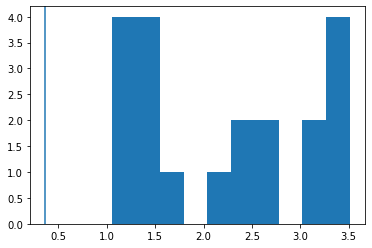

In [30]:
data_param_list = [data['args'].sig_w for data in dataset]
delw1_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][0][-1])) for data in dataset]
delw2_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][1][-1])) for data in dataset]
delw3_norm = [np.linalg.norm(utils.recover_matrix(data['delW'][2][-1])) for data in dataset]

plt.figure()
plt.hist(delw1_norm)
plt.axvline(np.linalg.norm(data0['delW'][0][-1]['s']))

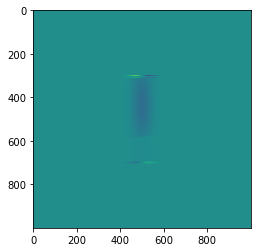

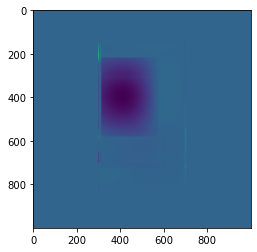

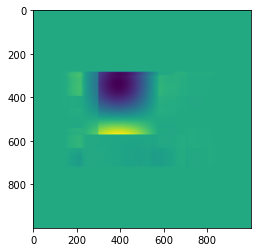

In [33]:
plt.figure()
plt.imshow(utils.recover_matrix(dataset[0]['delW'][0][-1]))
plt.figure()
plt.imshow(utils.recover_matrix(dataset[0]['delW'][1][-1]))
plt.figure()
plt.imshow(utils.recover_matrix(dataset[0]['delW'][2][-1]))

In [28]:
args2 = copy.copy(dataset[0]['args'])
probe_angles = np.linspace(0, 2*np.pi, 128, endpoint=False)
bl_net = model.Model(args2)

J_list = []

for _data in dataset:
    if _data['error'][-1] > 0.16:
        continue
    trained_net = model.Model(args2)
    utils.load_GD_changes(trained_net, _data)

    J = np.zeros(len(probe_angles))
    for i in trange(len(probe_angles)):
        args2.theta = probe_angles[i]
        
        probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        
        J[i] = r_utils.get_mean_field_fi(trained_net, probe_stim)

    J_list.append(J)



100%|██████████| 128/128 [00:02<00:00, 45.65it/s]


100%|██████████| 128/128 [00:02<00:00, 47.82it/s]


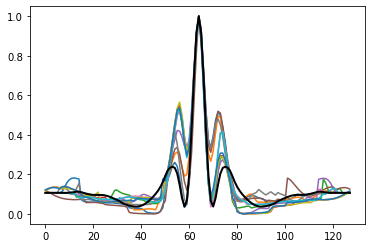

In [29]:
trained_net = model.Model(args2)
utils.load_GD_changes(trained_net, data0)
J0 = np.zeros(len(probe_angles))
for i in trange(len(probe_angles)):
    args2.theta = probe_angles[i]

    probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)

    J0[i] = r_utils.get_mean_field_fi(trained_net, probe_stim)

plt.figure()
for j in J_list:
    plt.plot(j)

plt.plot(J0, color='k', lw=2)